In [3]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import special

In [4]:
import scienceplots
plt.style.use("science")

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi']=120 #default is 72. 

In [5]:
prob_data = pd.read_csv("survival_probability_new.csv",sep=",")

x= prob_data["x (L/E)"]
P_ee= prob_data["P_ee"]
P_ee_err= prob_data["P_ee_err"]

prob_data.head()

,x (L/E),P_ee,P_ee_err_min,P_ee_err_max,P_ee_err
0,23.261848,0.588141,0.528376,0.649788,0.121412
1,28.602149,0.639309,0.585662,0.695780,0.110118
2,30.937424,0.687725,0.629842,0.748901,0.119059
3,32.780057,0.866976,0.795917,0.935682,0.139765
4,34.497508,0.722935,0.662700,0.783642,0.120941


In [6]:
neutrino_flux = pd.read_csv("neutrino_flux.txt", sep="\s+")

In [7]:
L_reactor = neutrino_flux['Distance_km'].to_numpy()[:16] # Only Japan reactors
Phi = neutrino_flux['Flux_cm2_s'].to_numpy()[:16] # Only Japan reactors

L_avg = np.sum(L_reactor*Phi)/np.sum(Phi)

print(f"The flux-weighted average reactor baseline is L = {L_avg:.2f} km.")

The flux-weighted average reactor baseline is L = 188.43 km.


### Neutrino survival probability

The neutrino survival probability ($P_{ee}$) in vacuum is as follows:

Vacuum survival probability:

$$P_{ee} = 1 - \cos^4\theta_{13}\,\sin^2(2\theta_{12})\,\sin^2\Delta_{21} - \sin^2(2\theta_{13})
\left(\cos^2\theta_{12}\,\sin^2\Delta_{31}+ \sin^2\theta_{12}\,\sin^2\Delta_{32}\right),$$

with, $$\Delta_{ij} = \frac{\Delta m_{ij}^2 L}{4E}$$


In [47]:
# def P_ee_vacuum(dm21, theta12, theta13, L, E):

#     x= L/E # in m/MeV unit
    
#     P_ee = 1 - np.cos(theta13)**4 * np.sin(2*theta12)**2 * np.sin(1.27*dm21*x* 10**(-2)) 
#     - 0.5 * np.sin(2*theta13)**2

#     return P_ee

def P_ee_vacuum(dm21, theta12, theta13, L, E):
    
    #Three-flavor vacuum survival probability for reactor antineutrinos
    
    dm31=2.50e-3
    
    dm32 = dm31 - dm21

    # E_GeV = E # / 1000.0   # convert MeV → GeV

    Delta21 = 1.267 * dm21 * L * 1e3 / E # To make the unit of L meter (m). 
    Delta31 = 1.267 * dm31 * L * 1e3 / E
    Delta32 = 1.267 * dm32 * L * 1e3 / E

    s12, c12 = np.sin(theta12), np.cos(theta12)
    s13, c13 = np.sin(theta13), np.cos(theta13)

    Pee = (
        1
        - 4 * (c12**2 * c13**2) * (s12**2 * c13**2) * np.sin(Delta21)**2
        - 4 * (c12**2 * c13**2) * (s13**2)        * np.sin(Delta31)**2
        - 4 * (s12**2 * c13**2) * (s13**2)        * np.sin(Delta32)**2
    )
    
    return Pee

In [85]:
def P_ee_flux_weighted(x_values, dm21, theta12, theta13):
    
    x_values = np.asarray(x_values)
    
    P_ee_weighted= np.zeros_like(x_values,dtype=float)

    for i,x in enumerate(x_values):  

        E = 180/x # in MeV

        Pee= np.array([P_ee_vacuum(dm21, theta12, theta13, L, E) for L in L_reactor])

        P_ee_weighted[i]= np.sum(Pee * Phi)/np.sum(Phi)

    return P_ee_weighted

In [86]:
def P_ee_fw_binned(x_centers, dx, dm21, theta12, theta13, n_sub=20):
    
    x_centers = np.asarray(x_centers)
    Pee_binned = np.zeros_like(x_centers, dtype=float)

    for i, xc in enumerate(x_centers):
        x_samples = np.linspace(xc - dx/2, xc + dx/2, n_sub)

        Pee_samples = []
        for x in x_samples:
            E = 180/ x
            Pee_reactors = np.array([
                P_ee_vacuum(dm21, theta12, theta13, L, E)
                for L in L_reactor
            ])
            Pee_samples.append(np.sum(Phi * Pee_reactors) / np.sum(Phi))

        Pee_binned[i] = np.mean(Pee_samples)

    return Pee_binned

In [87]:
x = prob_data["x (L/E)"].to_numpy()
P_data = prob_data["P_ee"].to_numpy()
P_err = prob_data["P_ee_err"].to_numpy()

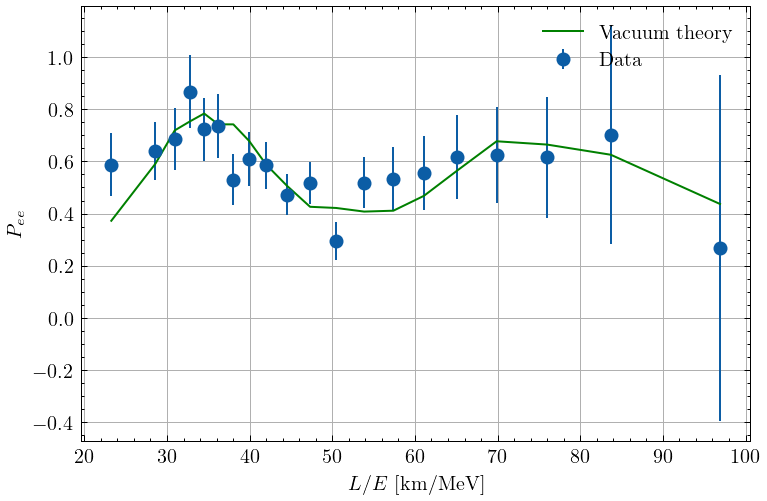

In [88]:
# theory prediction at bin centres
dm21_test = 7.5e-5
th12_test = 0.59
th13_test = 0.15

P_th = P_ee_flux_weighted(x, dm21_test, th12_test, th13_test)

plt.errorbar(x, P_data, yerr=P_err, fmt='o', label='Data')
plt.plot(x, P_th, color="g",label='Vacuum theory')
plt.xlabel(r'$L/E$ [km/MeV]')
plt.ylabel(r'$P_{ee}$')
plt.legend()
plt.grid()
plt.show()

In [89]:
P_ee_fw_binned(x, dx, dm21_test, th12_test, th13_test)

array([0.36704229, 0.59597658, 0.69874769, 0.74964455, 0.7706341 ,
       0.76271693, 0.72827003, 0.66997866, 0.59409682, 0.50958127,
       0.44292431, 0.41384129, 0.41335369, 0.4193058 , 0.47441572,
       0.59013697, 0.68810192, 0.65186855, 0.6131089 , 0.44107223])

In [140]:
dx = np.median(np.diff(x))
P_ee_fw_binned(x, dx, dm21_test, th12_test, th13_test)

array([0.76493453, 0.78703867, 0.82653255, 0.71802254, 0.76198104,
       0.73712357, 0.83433734, 0.7712087 , 0.78770635, 0.81090508,
       0.71574807, 0.75673072, 0.82053962, 0.81272959, 0.78606619,
       0.73354602, 0.8026735 , 0.77575509, 0.70392361, 0.78454096])

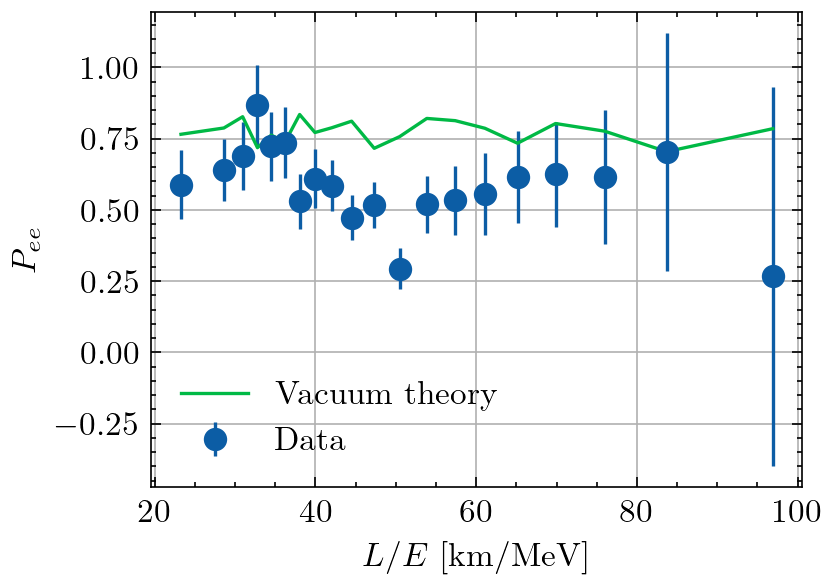

In [136]:
plt.errorbar(x, P_data, yerr=P_err, fmt='o', label='Data')
plt.plot(x, P_ee_fw_binned(x, dx, dm21_test, th12_test, th13_test), label='Vacuum theory')
plt.xlabel(r'$L/E$ [km/MeV]')
plt.ylabel(r'$P_{ee}$')
plt.legend()
plt.grid()
plt.show()

In [90]:
def chi2_vacuum(params):

    dm21, theta12, theta13 = params
    P_th = P_ee_fw_binned(x, dx, dm21, theta12, theta13)

    chi2 = np.sum(((P_data - P_th)/P_err)**2)

    return chi2

In [91]:
chi2_vacuum([7.5e-5, 0.6, 0.15])

15.601753237130547

In [144]:
from scipy.optimize import minimize

initial = [7.5e-5, 0.6, 0.15]

res = minimize(chi2_vacuum, initial)

dm21_best, theta12_best, theta13_best = res.x
print(res.x)

[7.98258024e-05 5.16485218e-01 2.56872984e-01]


In [111]:
res.hess_inv

array([[ 5.27163073e-12,  3.97170879e-09, -2.52449857e-08],
       [ 3.97170879e-09,  1.99256067e-03, -2.75291890e-03],
       [-2.52449857e-08, -2.75291890e-03,  5.04847378e-03]])

In [157]:
cov = res.hess_inv        # covariance matrix
errors = np.sqrt(np.diag(cov))

# print("Best-fit parameters:", res.x)
print("Parameter errors:", errors)

Parameter errors: [2.29600321e-06 4.46381078e-02 7.10526127e-02]


In [103]:
res.keys()

dict_keys(['fun', 'jac', 'hess_inv', 'nfev', 'njev', 'status', 'success', 'message', 'x', 'nit'])

In [109]:
res.message

'Desired error not necessarily achieved due to precision loss.'

### Contour plots

In [145]:
dm21_grid = np.linspace(5e-5, 12e-5, 60)
th12_grid = np.linspace(0.4, 0.9, 60)

X, Y = np.meshgrid(dm21_grid,th12_grid)

chi2_map = np.zeros_like(X)

X.shape

(60, 60)

In [146]:
for j, th12 in enumerate(th12_grid):
    for i, dm21 in enumerate(dm21_grid):
        chi2_map[j, i] = chi2_vacuum([dm21, th12, theta13_best])

In [147]:
chi2_min = res.fun
delta_chi2 = chi2_map - chi2_min

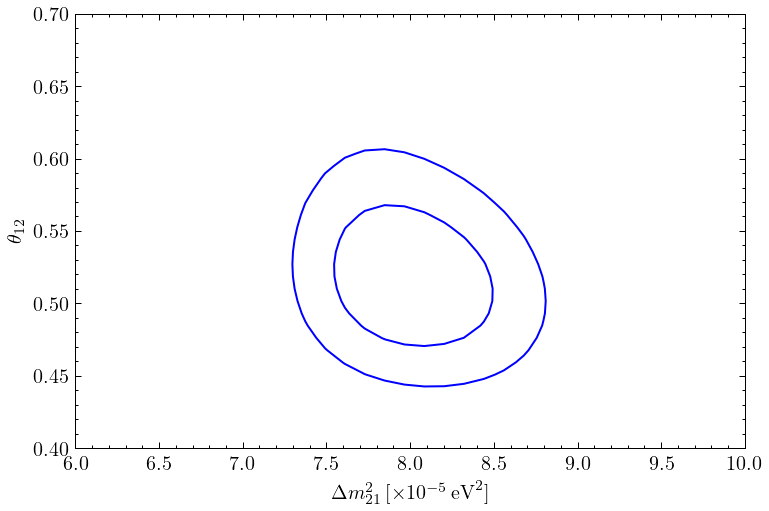

In [156]:
levels = [2.30, 6.18]

plt.contour(
    X*1e5,
    Y,
    delta_chi2,
    levels=levels,
    colors=['blue','blue']
)
plt.xlabel(r'$\Delta m^2_{21}\, [\times 10^{-5}\, \rm{eV}^2]$')
plt.ylabel(r'$\theta_{12}$')

plt.xlim(6,10)
plt.ylim(0.4,0.7)
plt.show()

### Fitting with UltraNest

In [62]:
param_names = [r'$\Delta m^{2}_{21}$', r'$\theta_{12}$', r'$\theta_{13}$']

In [137]:
import scipy.stats

def my_prior_transform(cube): # The prior list for parameters
    params = cube.copy()

    # dm21 varies between [1-15]* 10^(-5) eV^2
    hi= 15
    lo= 1
    params[0] = (cube[0] * (15 - 1) + 1)*1e-5

    # theta_12 varies within [0-1]
    params[1] = cube[1]

    # theta_13 varies within [0-1]
    params[2] = cube[2]

    return params

In [134]:
from numpy import log
dx=np.median(np.diff(x))

def my_likelihood(params):
    dm21, theta12, theta13 = params
    
    # compute intensity at every x position according to the model
    P_th = P_ee_fw_binned(x,dx,dm21, theta12, theta13)
    
    # compare model and data with gaussian likelihood:
    chi2 = np.sum(((P_data - P_th)/P_ee_err)**2)
    like = -0.5 * chi2
    return like

In [138]:
print(my_likelihood([7.5e-5, 0.59, 0.15]))
print(my_likelihood([8.5e-5, 0.59, 0.15]))
print(my_likelihood([7.5e-5, 0.75, 0.15]))

-7.672458176691573
-7.366645630745819
-12.305647066202416


In [140]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, 
                                          my_likelihood, 
                                          my_prior_transform,
                                         )

In [67]:
result = sampler.run(show_status=False, viz_callback=None)
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...
[ultranest] Explored until L=-5  
[ultranest] Likelihood function evaluations: 17142
[ultranest]   logZ = -11.3 +- 0.06837
[ultranest] Effective samples strategy satisfied (ESS = 1937.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.07, need <0.5)
[ultranest]   logZ error budget: single: 0.11 bs:0.07 tail:0.01 total:0.07 required:<0.50
[ultranest] done iterating.

logZ = -11.311 +- 0.123
  single instance: logZ = -11.311 +- 0.105
  bootstrapped   : logZ = -11.299 +- 0.123
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    $\Delta m^{2}_{21}$ : 0.0000100│▁▁▁▁▁▁▁▁▁     ▁      ▁▁▁▁▄▇▇▄▁▁▁▁ ▁▁▁▁ │0.0001167    0.0000829 +- 0.0000089
    $\theta_{12}$       : 0.00  │▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▃▅▇▇▇▇▅▂▁▁▁▁▁▁▁▁▁▁▁▂▃▆│1.00      0.60 +- 0.19
    $\theta_{13}$       : 0.00  │▅▅▅▅▅▇

In [68]:
samples = result['samples'].copy()
samples[:, 0] *= 1e5
samples[:, 0]

array([7.73144956, 8.65035868, 8.19643891, ..., 7.62750095, 8.58981367,
       8.33517775])

In [96]:
result_plot = result.copy()
result_plot['samples'] = samples
result_plot['maximum_likelihood']['point'][0] = result_plot['maximum_likelihood']['point'][0]*1e5
result_plot['samples']

array([[7.73144956, 0.98219325, 0.17353088],
       [8.65035868, 0.96729279, 0.1360328 ],
       [8.19643891, 0.39215012, 0.41262474],
       ...,
       [7.62750095, 0.55490316, 0.28199688],
       [8.58981367, 0.51852638, 0.25457236],
       [8.33517775, 0.45523651, 0.37685798]])

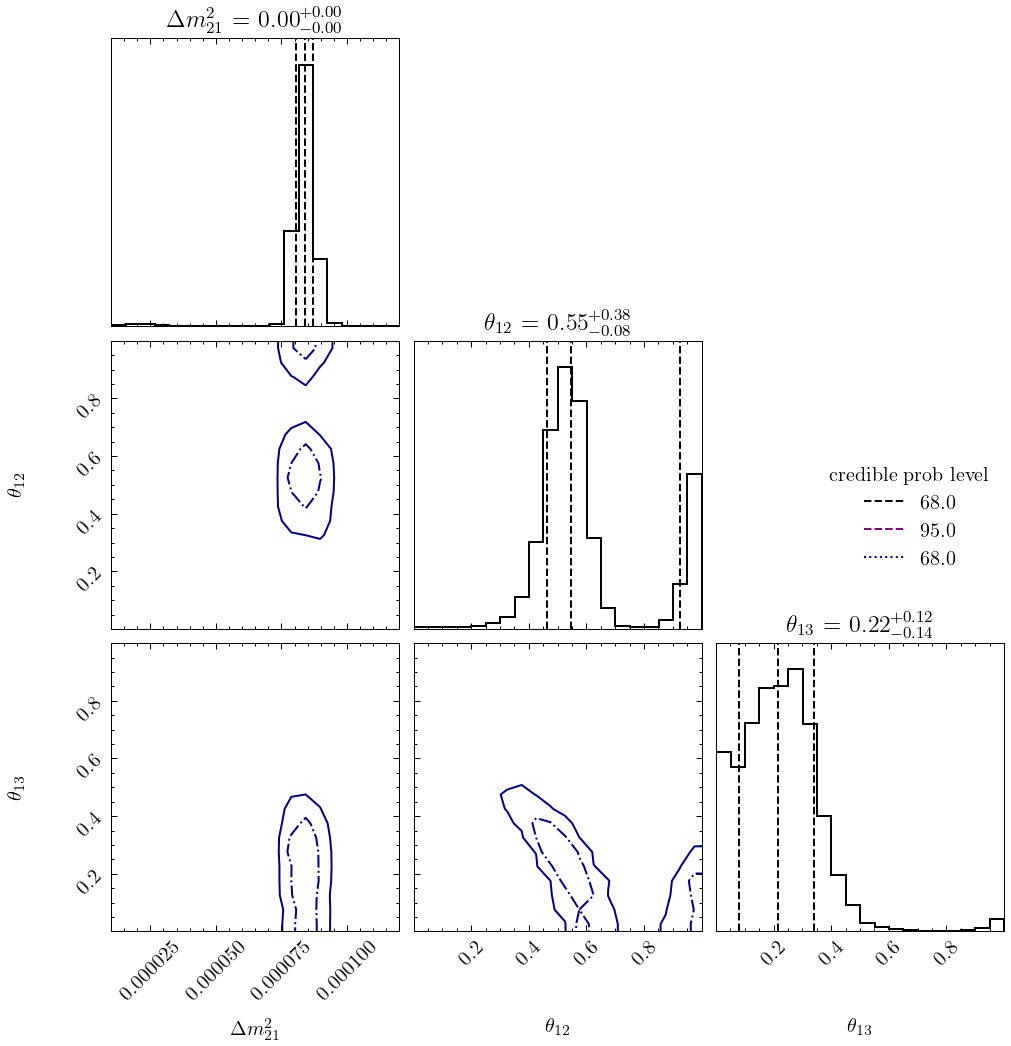

In [115]:
from ultranest.plot import cornerplot
fig= cornerplot(result_plot,
                # plot_datapoints=True, 
                levels=[0.68, 0.95],
                quantiles=[0.16,0.5, 0.84],
                # show_titles=False,
                color='black',
                # plot_contour_labels=False
               );

# plt.tight_layout()
# plt.legend().remove()

plt.show()

In [93]:
result.keys()

dict_keys(['niter', 'logz', 'logzerr', 'logz_bs', 'logz_single', 'logzerr_tail', 'logzerr_bs', 'ess', 'H', 'Herr', 'posterior', 'weighted_samples', 'samples', 'maximum_likelihood', 'ncall', 'paramnames', 'logzerr_single', 'insertion_order_MWW_test'])

In [95]:
result['maximum_likelihood']['point'][0]

8.355961803630634e-05